# Libraries

💡 **Environment:** `gpu-kmeans`  

In [ ]:
import csv
import gc
from pathlib import Path
import numpy as np
import pandas as pd
from pyprojroot.here import here
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score as ari
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
import cupy as cp
from cuml.cluster import KMeans as cuKMeans
import numpy as np
import pandas as pd
import cupy as cp
from cuml.cluster import KMeans as cuKMeans
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu


# Input

In [ ]:
path = here('data/gtex/GTEx_Analysis_v8_Annotations_SampleAttributesDS.txt')

gtex_meta = pd.read_csv(
    path,
    sep='\t',
    header=0,
    dtype=str,
    quoting=csv.QUOTE_NONE,   
    engine='python',
    comment=None,            
    keep_default_na=False,
    on_bad_lines='warn'     
)

print(gtex_meta.shape)
gtex_meta.head()

(22951, 63)


,SAMPID,SMATSSCR,SMCENTER,SMPTHNTS,SMRIN,SMTS,SMTSD,SMUBRID,SMTSISCH,SMTSPAX,...,SME1ANTI,SMSPLTRD,SMBSMMRT,SME1SNSE,SME1PCTS,SMRRNART,SME1MPRT,SMNUM5CD,SMDPMPRT,SME2PCTS
0,GTEX-1117F-0003-SM-58Q7G,,B1,,,Blood,Whole Blood,0013756,1188,,...,,,,,,,,,,
1,GTEX-1117F-0003-SM-5DWSB,,B1,,,Blood,Whole Blood,0013756,1188,,...,,,,,,,,,,
2,GTEX-1117F-0003-SM-6WBT7,,B1,,,Blood,Whole Blood,0013756,1188,,...,,,,,,,,,,
3,GTEX-1117F-0011-R10a-SM-AHZ7F,,"B1, A1",,,Brain,Brain - Frontal Cortex (BA9),0009834,1193,,...,,,,,,,,,,
4,GTEX-1117F-0011-R10b-SM-CYKQ8,,"B1, A1",,7.2,Brain,Brain - Frontal Cortex (BA9),0009834,1193,,...,,,,,,,,,,


In [ ]:
display(gtex_meta['SMTS'].value_counts())
total_tissues = len(gtex_meta['SMTS'].value_counts())
total_tissues

SMTS
Blood              3480
Brain              3326
Skin               2014
Esophagus          1582
Blood Vessel       1473
Adipose Tissue     1327
Heart              1141
Muscle             1132
Lung                867
Colon               821
Thyroid             812
Nerve               722
Breast              480
Testis              406
Stomach             381
Pancreas            360
Pituitary           301
Adrenal Gland       275
Prostate            262
Spleen              260
Liver               251
Bone Marrow         217
Ovary               195
Small Intestine     193
Salivary Gland      181
Vagina              173
Uterus              166
Kidney              104
Bladder              21
Cervix Uteri         19
Fallopian Tube        9
Name: count, dtype: int64

31

Keep samples in expression and in metadata

In [ ]:
gtex_data = pd.read_csv(here('output/gtex/df_gtex_fbm_filt.csv'), index_col=0)

In [ ]:
meta = gtex_meta.copy()
if meta.index.name != "SAMPID":
    meta = meta.set_index("SAMPID")

sample_ids_expr = pd.Index(gtex_data.columns.astype(str).str.strip(), name="SAMPID")
sample_ids_meta = meta.index.astype(str).str.strip()
common_ids = sample_ids_expr.intersection(sample_ids_meta)

if len(common_ids) == 0:
    raise ValueError("No overlapping sample IDs between expression and metadata.")

gtex_data_common = gtex_data.loc[:, common_ids]    
meta_common = meta.loc[common_ids] 

In [ ]:
y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

# GPU kmeans ensemble

## Parameters

In [ ]:
# int(np.sqrt(gtex_data_scaled.shape[1]))

In [ ]:
INITIAL_RANDOM_STATE = 10000
K_MIN = 20
K_MAX = 40
K_STEP = 5
N_REPS_PER_K = 50
KMEANS_N_INIT = 10

print("INITIAL_RANDOM_STATE:", INITIAL_RANDOM_STATE)
print("K_MIN:", K_MIN)
print("K_MAX:", K_MAX)
print("K_STEP:", K_STEP)
print("N_REPS_PER_K:", N_REPS_PER_K)
print("KMEANS_N_INIT:", KMEANS_N_INIT)
print("total_tissues:", total_tissues)

INITIAL_RANDOM_STATE: 10000
K_MIN: 20
K_MAX: 40
K_STEP: 5
N_REPS_PER_K: 50
KMEANS_N_INIT: 10
total_tissues: 31


## RNA-Seq

In [ ]:
B = gtex_data.copy()
B.columns = B.columns.astype(str).str.strip()

common_ids = B.columns.intersection(meta.index)

B_common = B.loc[:, common_ids]
B_t = B_common.T.astype(np.float32)

scaler = StandardScaler()
B_scaled = scaler.fit_transform(B_t)

y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

In [ ]:
X_gpu = cp.asarray(B_scaled.astype("float32"))

records = []
best = {"ari": -np.inf, "k": None, "seed": None, "labels": None}

k_values = list(range(K_MIN, K_MAX + 1, K_STEP))
if total_tissues not in k_values:
    k_values.append(total_tissues)
    k_values = sorted(set(k_values)) 

for k in k_values:
    for rep in range(N_REPS_PER_K):
        km = cuKMeans(
            n_clusters=k,
            init="k-means++",
            random_state=INITIAL_RANDOM_STATE,
            max_iter=300,
            tol=1e-4,
            verbose=0
        )
        labels_gpu = km.fit_predict(X_gpu)
        labels = cp.asnumpy(labels_gpu)
        ari = adjusted_rand_score(y_true, labels)

        records.append({
            "k": k,
            "rep": rep,
            "seed": INITIAL_RANDOM_STATE,
            "ari": ari
        })

        INITIAL_RANDOM_STATE += 1

In [ ]:
gtex_rnaseq_kmeans_results_df = (
    pd.DataFrame.from_records(records)
      .sort_values(["ari", "k"], ascending=[False, True])
      .reset_index(drop=True)
)

gtex_rnaseq_kmeans_results_df.groupby("k")["ari"].mean().reset_index().sort_values('ari', ascending=False)
mean_ari = gtex_rnaseq_kmeans_results_df.groupby("k")["ari"].mean()
best_k = mean_ari.idxmax()
best_k_gtex_rnaseq_kmeans_results_df = gtex_rnaseq_kmeans_results_df[gtex_rnaseq_kmeans_results_df["k"] == best_k]

## CLAMP

In [ ]:
gtex_full_B = pd.read_csv(here('output/gtex/CLAMPfull/B.csv'), index_col=0)
gtex_full_B.head()

,GTEX-1117F-0226-SM-5GZZ7,GTEX-1117F-0426-SM-5EGHI,GTEX-1117F-0526-SM-5EGHJ,GTEX-1117F-0626-SM-5N9CS,GTEX-1117F-0726-SM-5GIEN,GTEX-1117F-1326-SM-5EGHH,GTEX-1117F-2426-SM-5EGGH,GTEX-1117F-2526-SM-5GZY6,GTEX-1117F-2826-SM-5GZXL,GTEX-1117F-2926-SM-5GZYI,...,GTEX-ZZPU-1126-SM-5N9CW,GTEX-ZZPU-1226-SM-5N9CK,GTEX-ZZPU-1326-SM-5GZWS,GTEX-ZZPU-1426-SM-5GZZ6,GTEX-ZZPU-1826-SM-5E43L,GTEX-ZZPU-2126-SM-5EGIU,GTEX-ZZPU-2226-SM-5EGIV,GTEX-ZZPU-2426-SM-5E44I,GTEX-ZZPU-2626-SM-5E45Y,GTEX-ZZPU-2726-SM-5NQ8O
LV1,0.126962,0.242845,0.112547,0.131382,0.206810,0.157447,-0.086056,-0.035215,0.045329,0.049398,...,0.142876,0.189193,-0.022878,0.028563,0.049785,0.028518,-0.033724,0.116553,0.029912,0.101010
LV2,-0.126591,-0.289777,-0.155047,-0.111255,-0.193223,-0.222042,-0.089704,-0.114371,-0.232414,-0.158311,...,-0.170311,-0.058008,-0.137261,-0.203871,-0.144149,-0.035868,-0.208469,-0.147182,-0.292285,-0.263875
LV3,-0.267398,-0.124027,-0.264551,-0.130424,0.248946,-0.180543,-0.143631,0.182787,-0.122651,0.028742,...,0.484360,0.101094,0.048706,0.139665,0.052260,-0.201717,0.199625,-0.085103,-0.046922,-0.102690
LV4,0.851155,-0.094054,0.049613,-0.026647,0.076737,0.118392,0.178671,-0.050073,0.232374,0.367757,...,0.041931,-0.002543,0.106505,0.137103,-0.054901,0.211083,-0.212637,-0.106822,-0.143774,0.229845
LV5,-0.136672,-0.076751,-0.101498,0.041620,0.055853,0.046964,-0.174810,0.277909,-0.077781,0.045638,...,0.071390,0.026299,-0.008172,-0.002542,-0.062518,-0.128393,0.211309,-0.076817,-0.031829,-0.057233


In [ ]:
gtex_base_B = pd.read_csv(here('output/gtex/gtex_baseRes/gtex_B.csv'), index_col=0)
gtex_base_B.head()

,GTEX-1117F-0226-SM-5GZZ7,GTEX-1117F-0426-SM-5EGHI,GTEX-1117F-0526-SM-5EGHJ,GTEX-1117F-0626-SM-5N9CS,GTEX-1117F-0726-SM-5GIEN,GTEX-1117F-1326-SM-5EGHH,GTEX-1117F-2426-SM-5EGGH,GTEX-1117F-2526-SM-5GZY6,GTEX-1117F-2826-SM-5GZXL,GTEX-1117F-2926-SM-5GZYI,...,GTEX-ZZPU-1126-SM-5N9CW,GTEX-ZZPU-1226-SM-5N9CK,GTEX-ZZPU-1326-SM-5GZWS,GTEX-ZZPU-1426-SM-5GZZ6,GTEX-ZZPU-1826-SM-5E43L,GTEX-ZZPU-2126-SM-5EGIU,GTEX-ZZPU-2226-SM-5EGIV,GTEX-ZZPU-2426-SM-5E44I,GTEX-ZZPU-2626-SM-5E45Y,GTEX-ZZPU-2726-SM-5NQ8O
LV1,1.093983,-1.044800,0.986197,1.116386,-0.643033,-0.052175,1.711572,0.813820,0.576763,0.366468,...,-0.760228,-0.016332,1.015890,-0.216868,0.451997,1.470993,-0.250063,0.616404,-1.245626,0.411112
LV2,-0.678981,-0.556042,-0.506765,-0.488907,-0.285915,-0.708258,-0.077878,-0.787619,-0.731589,-0.690534,...,-0.383007,-0.402949,-0.559046,-0.465875,-0.287258,-0.086368,-0.915894,-0.472114,-0.699259,-0.922378
LV3,-0.049917,-1.221859,-0.689375,-0.785674,-0.780599,-0.175877,-0.438129,1.306882,-0.295764,0.677273,...,-1.174502,-0.280814,0.515104,0.062110,-1.444096,-0.823211,1.128037,-1.643464,-1.599611,-0.786882
LV4,0.470260,-0.714816,0.840538,1.214442,0.674955,0.752638,0.993329,-2.081230,0.266215,-1.142407,...,0.264438,-0.328399,-0.082028,-0.352728,0.544860,0.203134,-2.832134,0.964860,-1.124305,0.569221
LV5,-0.076680,-0.271628,-0.322932,-0.295110,0.198468,-0.191243,-0.044676,2.037918,0.243564,2.118099,...,-0.029262,-0.526803,0.743393,0.380844,-0.399635,-0.086873,1.764374,-0.542477,-0.653654,-0.631152


In [ ]:
B = gtex_full_B.copy()
B.columns = B.columns.astype(str).str.strip()

common_ids = B.columns.intersection(meta.index)

B_common = B.loc[:, common_ids]
B_t = B_common.T.astype(np.float32)

scaler = StandardScaler()
B_scaled = scaler.fit_transform(B_t)

y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

In [ ]:
X_gpu = cp.asarray(B_scaled.astype("float32"))

records = []

for k in k_values:
    for rep in range(N_REPS_PER_K):
        km = cuKMeans(
            n_clusters=k,
            init="k-means++",
            random_state=INITIAL_RANDOM_STATE,
            max_iter=300,
            tol=1e-4,
            verbose=0
        )
        labels_gpu = km.fit_predict(X_gpu)
        labels = cp.asnumpy(labels_gpu)
        ari = adjusted_rand_score(y_true, labels)

        records.append({
            "k": k,
            "rep": rep,
            "seed": INITIAL_RANDOM_STATE,
            "ari": ari
        })

        INITIAL_RANDOM_STATE += 1
        

In [ ]:
gtex_full_kmeans_results_df = (
    pd.DataFrame.from_records(records)
      .sort_values(["ari", "k"], ascending=[False, True])
      .reset_index(drop=True)
)

gtex_full_kmeans_results_df.groupby("k")["ari"].mean().reset_index().sort_values('ari', ascending=False)
mean_ari = gtex_full_kmeans_results_df.groupby("k")["ari"].mean()
best_k = mean_ari.idxmax()
best_k_gtex_full_kmeans_results_df = gtex_full_kmeans_results_df[gtex_full_kmeans_results_df["k"] == best_k]

In [ ]:
B = gtex_base_B.copy()
B.columns = B.columns.astype(str).str.strip()

common_ids = B.columns.intersection(meta.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping sample IDs between B and metadata.")

B_common = B.loc[:, common_ids]
B_t = B_common.T.astype(np.float32)

scaler = StandardScaler()
B_scaled = scaler.fit_transform(B_t)

y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

X_gpu = cp.asarray(B_scaled.astype("float32"))

records = []

for k in k_values:
    for rep in range(N_REPS_PER_K):
        km = cuKMeans(
            n_clusters=k,
            init="k-means++",
            random_state=INITIAL_RANDOM_STATE,
            max_iter=300,
            tol=1e-4,
            verbose=0
        )
        labels_gpu = km.fit_predict(X_gpu)
        labels = cp.asnumpy(labels_gpu)
        ari = adjusted_rand_score(y_true, labels)

        records.append({
            "k": k,
            "rep": rep,
            "seed": INITIAL_RANDOM_STATE,
            "ari": ari
        })

        INITIAL_RANDOM_STATE += 1

In [ ]:
gtex_base_kmeans_results_df = (
    pd.DataFrame.from_records(records)
      .sort_values(["ari", "k"], ascending=[False, True])
      .reset_index(drop=True)
)

gtex_base_kmeans_results_df.groupby("k")["ari"].mean().reset_index().sort_values('ari', ascending=False)
mean_ari = gtex_base_kmeans_results_df.groupby("k")["ari"].mean()
best_k = mean_ari.idxmax()
best_k_gtex_base_kmeans_results_df = gtex_base_kmeans_results_df[gtex_base_kmeans_results_df["k"] == best_k]

## GenomicSuperSignature

In [ ]:
gtex_GenomicSuperSignature_B = pd.read_csv(here("output/gtex/GenomicSuperSignature/gtex_B.csv"), index_col=0)

B = gtex_flashier_B.copy()
B.columns = B.columns.astype(str).str.strip()

common_ids = B.columns.intersection(meta.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping sample IDs between B and metadata.")

B_common = B.loc[:, common_ids]
B_t = B_common.T.astype(np.float32)

scaler = StandardScaler()
B_scaled = scaler.fit_transform(B_t)

y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

X_gpu = cp.asarray(B_scaled.astype("float32"))

records = []

for k in k_values:
    for rep in range(N_REPS_PER_K):
        km = cuKMeans(
            n_clusters=k,
            init="k-means++",
            random_state=INITIAL_RANDOM_STATE,
            max_iter=300,
            tol=1e-4,
            verbose=0
        )
        labels_gpu = km.fit_predict(X_gpu)
        labels = cp.asnumpy(labels_gpu)
        ari = adjusted_rand_score(y_true, labels)

        records.append({
            "k": k,
            "rep": rep,
            "seed": INITIAL_RANDOM_STATE,
            "ari": ari
        })

        INITIAL_RANDOM_STATE += 1


gtex_GenomicSuperSignature_kmeans_results_df = (
    pd.DataFrame.from_records(records)
      .sort_values(["ari", "k"], ascending=[False, True])
      .reset_index(drop=True)
)

gtex_GenomicSuperSignature_kmeans_results_df.groupby("k")["ari"].mean().reset_index().sort_values('ari', ascending=False)
mean_ari = gtex_GenomicSuperSignature_kmeans_results_df.groupby("k")["ari"].mean()
best_k = mean_ari.idxmax()
best_k_gtex_GenomicSuperSignature_kmeans_results_df = gtex_GenomicSuperSignature_kmeans_results_df[gtex_GenomicSuperSignature_kmeans_results_df["k"] == best_k]

# Flashier

In [ ]:
gtex_flashier_B = pd.read_csv(here("output/gtex/flashier/gtex_B.csv"), index_col=0)

B = gtex_flashier_B.copy()
B.columns = B.columns.astype(str).str.strip()

common_ids = B.columns.intersection(meta.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping sample IDs between B and metadata.")

B_common = B.loc[:, common_ids]
B_t = B_common.T.astype(np.float32)

scaler = StandardScaler()
B_scaled = scaler.fit_transform(B_t)

y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

X_gpu = cp.asarray(B_scaled.astype("float32"))

records = []

for k in k_values:
    for rep in range(N_REPS_PER_K):
        km = cuKMeans(
            n_clusters=k,
            init="k-means++",
            random_state=INITIAL_RANDOM_STATE,
            max_iter=300,
            tol=1e-4,
            verbose=0
        )
        labels_gpu = km.fit_predict(X_gpu)
        labels = cp.asnumpy(labels_gpu)
        ari = adjusted_rand_score(y_true, labels)

        records.append({
            "k": k,
            "rep": rep,
            "seed": INITIAL_RANDOM_STATE,
            "ari": ari
        })

        INITIAL_RANDOM_STATE += 1


gtex_flashier_kmeans_results_df = (
    pd.DataFrame.from_records(records)
      .sort_values(["ari", "k"], ascending=[False, True])
      .reset_index(drop=True)
)

gtex_flashier_kmeans_results_df.groupby("k")["ari"].mean().reset_index().sort_values('ari', ascending=False)
mean_ari = gtex_flashier_kmeans_results_df.groupby("k")["ari"].mean()
best_k = mean_ari.idxmax()
best_k_gtex_flashier_kmeans_results_df = gtex_flashier_kmeans_results_df[gtex_flashier_kmeans_results_df["k"] == best_k]

# MOFA FLEX

In [ ]:
gtex_mofa_B = pd.read_csv(here("output/gtex/mofa/gtex_B.csv"), index_col=0)

B = gtex_mofa_B.copy()
B.columns = B.columns.astype(str).str.strip()

common_ids = B.columns.intersection(meta.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping sample IDs between B and metadata.")

B_common = B.loc[:, common_ids]
B_t = B_common.T.astype(np.float32)

scaler = StandardScaler()
B_scaled = scaler.fit_transform(B_t)

y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

X_gpu = cp.asarray(B_scaled.astype("float32"))

records = []

for k in k_values:
    for rep in range(N_REPS_PER_K):
        km = cuKMeans(
            n_clusters=k,
            init="k-means++",
            random_state=INITIAL_RANDOM_STATE,
            max_iter=300,
            tol=1e-4,
            verbose=0
        )
        labels_gpu = km.fit_predict(X_gpu)
        labels = cp.asnumpy(labels_gpu)
        ari = adjusted_rand_score(y_true, labels)

        records.append({
            "k": k,
            "rep": rep,
            "seed": INITIAL_RANDOM_STATE,
            "ari": ari
        })

        INITIAL_RANDOM_STATE += 1


gtex_mofa_kmeans_results_df = (
    pd.DataFrame.from_records(records)
      .sort_values(["ari", "k"], ascending=[False, True])
      .reset_index(drop=True)
)

gtex_mofa_kmeans_results_df.groupby("k")["ari"].mean().reset_index().sort_values('ari', ascending=False)
mean_ari = gtex_mofa_kmeans_results_df.groupby("k")["ari"].mean()
best_k = mean_ari.idxmax()
best_k_gtex_mofa_kmeans_results_df = gtex_mofa_kmeans_results_df[gtex_mofa_kmeans_results_df["k"] == best_k]

## PCA

In [ ]:
gtex_pca_B = pd.read_pickle(here("output/gtex/gtex_pca_B.pkl"))

B = gtex_pca_B.copy()
B.columns = B.columns.astype(str).str.strip()

common_ids = B.columns.intersection(meta.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping sample IDs between B and metadata.")

B_common = B.loc[:, common_ids]
B_t = B_common.T.astype(np.float32)

scaler = StandardScaler()
B_scaled = scaler.fit_transform(B_t)

y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

X_gpu = cp.asarray(B_scaled.astype("float32"))

records = []

for k in k_values:
    for rep in range(N_REPS_PER_K):
        km = cuKMeans(
            n_clusters=k,
            init="k-means++",
            random_state=INITIAL_RANDOM_STATE,
            max_iter=300,
            tol=1e-4,
            verbose=0
        )
        labels_gpu = km.fit_predict(X_gpu)
        labels = cp.asnumpy(labels_gpu)
        ari = adjusted_rand_score(y_true, labels)

        records.append({
            "k": k,
            "rep": rep,
            "seed": INITIAL_RANDOM_STATE,
            "ari": ari
        })

        INITIAL_RANDOM_STATE += 1


gtex_pca_kmeans_results_df = (
    pd.DataFrame.from_records(records)
      .sort_values(["ari", "k"], ascending=[False, True])
      .reset_index(drop=True)
)

gtex_pca_kmeans_results_df.groupby("k")["ari"].mean().reset_index().sort_values('ari', ascending=False)
mean_ari = gtex_pca_kmeans_results_df.groupby("k")["ari"].mean()
best_k = mean_ari.idxmax()
best_k_gtex_pca_kmeans_results_df = gtex_pca_kmeans_results_df[gtex_pca_kmeans_results_df["k"] == best_k]

## ICA

In [ ]:
gtex_ica_B = pd.read_pickle(here("output/gtex/gtex_ica_B.pkl"))

B = gtex_ica_B.copy()
B.columns = B.columns.astype(str).str.strip()

common_ids = B.columns.intersection(meta.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping sample IDs between B and metadata.")

B_common = B.loc[:, common_ids]
B_t = B_common.T.astype(np.float32)

scaler = StandardScaler()
B_scaled = scaler.fit_transform(B_t)

y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

X_gpu = cp.asarray(B_scaled.astype("float32"))

records = []

for k in k_values:
    for rep in range(N_REPS_PER_K):
        km = cuKMeans(
            n_clusters=k,
            init="k-means++",
            random_state=INITIAL_RANDOM_STATE,
            max_iter=300,
            tol=1e-4,
            verbose=0
        )
        labels_gpu = km.fit_predict(X_gpu)
        labels = cp.asnumpy(labels_gpu)
        ari = adjusted_rand_score(y_true, labels)

        records.append({
            "k": k,
            "rep": rep,
            "seed": INITIAL_RANDOM_STATE,
            "ari": ari
        })

        INITIAL_RANDOM_STATE += 1


gtex_ica_kmeans_results_df = (
    pd.DataFrame.from_records(records)
      .sort_values(["ari", "k"], ascending=[False, True])
      .reset_index(drop=True)
)

gtex_ica_kmeans_results_df.groupby("k")["ari"].mean().reset_index().sort_values('ari', ascending=False)
mean_ari = gtex_ica_kmeans_results_df.groupby("k")["ari"].mean()
best_k = mean_ari.idxmax()
best_k_gtex_ica_kmeans_results_df = gtex_ica_kmeans_results_df[gtex_ica_kmeans_results_df["k"] == best_k]

## NMF

In [ ]:
gtex_nmf_B = pd.read_pickle(here('output/gtex/gtex_nmf_B.pkl'))

In [ ]:
B = gtex_nmf_B.copy()
B.columns = B.columns.astype(str).str.strip()

common_ids = B.columns.intersection(meta.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping sample IDs between B and metadata.")

B_common = B.loc[:, common_ids]
B_t = B_common.T.astype(np.float32)

scaler = StandardScaler()
B_scaled = scaler.fit_transform(B_t)

y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

X_gpu = cp.asarray(B_scaled.astype("float32"))

records = []

for k in k_values:
    for rep in range(N_REPS_PER_K):
        km = cuKMeans(
            n_clusters=k,
            init="k-means++",
            random_state=INITIAL_RANDOM_STATE,
            max_iter=300,
            tol=1e-4,
            verbose=0
        )
        labels_gpu = km.fit_predict(X_gpu)
        labels = cp.asnumpy(labels_gpu)
        ari = adjusted_rand_score(y_true, labels)

        records.append({
            "k": k,
            "rep": rep,
            "seed": INITIAL_RANDOM_STATE,
            "ari": ari
        })

        INITIAL_RANDOM_STATE += 1

In [ ]:
gtex_nmf_kmeans_results_df = (
    pd.DataFrame.from_records(records)
      .sort_values(["ari", "k"], ascending=[False, True])
      .reset_index(drop=True)
)

gtex_nmf_kmeans_results_df.groupby("k")["ari"].mean().reset_index().sort_values('ari', ascending=False)
mean_ari = gtex_nmf_kmeans_results_df.groupby("k")["ari"].mean()
best_k = mean_ari.idxmax()
best_k_gtex_nmf_kmeans_results_df = gtex_nmf_kmeans_results_df[gtex_nmf_kmeans_results_df["k"] == best_k]

## PLIER

In [ ]:
gtex_PLIER_B = pd.read_csv(here('output/gtex/gtex_PLIER/gtex_B.csv'), index_col=0)
gtex_PLIER_B.head()

,GTEX-1117F-0226-SM-5GZZ7,GTEX-1117F-0426-SM-5EGHI,GTEX-1117F-0526-SM-5EGHJ,GTEX-1117F-0626-SM-5N9CS,GTEX-1117F-0726-SM-5GIEN,GTEX-1117F-1326-SM-5EGHH,GTEX-1117F-2426-SM-5EGGH,GTEX-1117F-2526-SM-5GZY6,GTEX-1117F-2826-SM-5GZXL,GTEX-1117F-2926-SM-5GZYI,...,GTEX-ZZPU-1126-SM-5N9CW,GTEX-ZZPU-1226-SM-5N9CK,GTEX-ZZPU-1326-SM-5GZWS,GTEX-ZZPU-1426-SM-5GZZ6,GTEX-ZZPU-1826-SM-5E43L,GTEX-ZZPU-2126-SM-5EGIU,GTEX-ZZPU-2226-SM-5EGIV,GTEX-ZZPU-2426-SM-5E44I,GTEX-ZZPU-2626-SM-5E45Y,GTEX-ZZPU-2726-SM-5NQ8O
"1,Cells - EBV-transformed Lymphocytes Male 40-49 Up",0.466173,-0.160275,0.731896,0.036733,-0.160367,0.270113,0.341554,0.187091,0.124304,0.175803,...,-0.235240,-0.045660,0.192526,-0.077122,0.188670,0.493667,0.083558,0.347007,-0.381354,0.233925
"2,Colon - Transverse Male 70-79 Up",-0.054827,0.031944,-0.071197,-0.037784,0.071309,-0.038628,-0.101235,-0.016071,-0.094175,-0.040418,...,0.037686,0.018231,-0.086882,0.194126,0.286908,-0.088851,0.038957,-0.066848,0.069557,-0.040093
LV 3,-0.189701,0.084745,-0.044215,-0.126897,-0.018912,-0.033255,-0.207986,0.893321,-0.003714,0.042962,...,-0.013777,-0.082808,0.009087,0.097938,0.053862,-0.197826,0.423213,0.078481,-0.023469,-0.052358
"4,Whole Blood Female 50-59 Up",-0.168352,-0.005647,-0.148825,-0.130289,0.044565,-0.144275,-0.090858,-0.087219,-0.070949,-0.137103,...,0.022824,-0.160525,-0.080125,-0.050213,-0.117355,-0.099323,-0.089000,-0.056325,0.000273,-0.061487
"5,Myc Targets V1",0.227845,0.135854,0.024891,0.149559,-0.351296,0.067057,0.042267,0.159246,0.305570,0.148720,...,-0.196135,0.171442,-0.187115,-0.061617,0.011573,0.046816,0.413043,-0.091984,0.284671,0.044441


In [ ]:
B = gtex_PLIER_B.copy()
B.columns = B.columns.astype(str).str.strip()

common_ids = B.columns.intersection(meta.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping sample IDs between B and metadata.")

B_common = B.loc[:, common_ids]
B_t = B_common.T.astype(np.float32)

scaler = StandardScaler()
B_scaled = scaler.fit_transform(B_t)

y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

X_gpu = cp.asarray(B_scaled.astype("float32"))

records = []

for k in k_values:
    for rep in range(N_REPS_PER_K):
        km = cuKMeans(
            n_clusters=k,
            init="k-means++",
            random_state=INITIAL_RANDOM_STATE,
            max_iter=300,
            tol=1e-4,
            verbose=0
        )
        labels_gpu = km.fit_predict(X_gpu)
        labels = cp.asnumpy(labels_gpu)
        ari = adjusted_rand_score(y_true, labels)

        records.append({
            "k": k,
            "rep": rep,
            "seed": INITIAL_RANDOM_STATE,
            "ari": ari
        })

        INITIAL_RANDOM_STATE += 1

In [ ]:
gtex_PLIER_kmeans_results_df = (
    pd.DataFrame.from_records(records)
      .sort_values(["ari", "k"], ascending=[False, True])
      .reset_index(drop=True)
)

gtex_PLIER_kmeans_results_df.groupby("k")["ari"].mean().reset_index().sort_values('ari', ascending=False)
mean_ari = gtex_PLIER_kmeans_results_df.groupby("k")["ari"].mean()
best_k = mean_ari.idxmax()
best_k_gtex_PLIER_kmeans_results_df = gtex_PLIER_kmeans_results_df[gtex_PLIER_kmeans_results_df["k"] == best_k]

## CLAMP different priors

In [ ]:
# gtex_GO_BP_CLAMP = pd.read_csv(here('output/gtex/gtex_GO_BP_CLAMP/gtex_B.csv'), index_col=0)
# gtex_KEGG_CLAMP = pd.read_csv(here('output/gtex/gtex_KEGG_CLAMP/gtex_B.csv'), index_col=0)
# gtex_GTEx_Tissues_CLAMP = pd.read_csv(here('output/gtex/gtex_GTEx_Tissues_CLAMP/gtex_B.csv'), index_col=0)
# gtex_CellMarker_2024_CLAMP = pd.read_csv(here('output/gtex/gtex_CellMarker_2024_CLAMP/gtex_B.csv'), index_col=0)


# display(gtex_GO_BP_CLAMP.head())
# display(gtex_KEGG_CLAMP.head())
# display(gtex_GTEx_Tissues_CLAMP.head())
# display(gtex_CellMarker_2024_CLAMP.head())

FileNotFoundError: [Errno 2] No such file or directory: '/home/msubirana/Documents/pivlab/clamp-analyses/output/gtex/gtex_GO_BP_PLIER2/gtex_B.csv'

In [ ]:
# B = gtex_GO_BP_CLAMP.copy()
# B.columns = B.columns.astype(str).str.strip()

# common_ids = B.columns.intersection(meta.index)
# if len(common_ids) == 0:
#     raise ValueError("No overlapping sample IDs between B and metadata.")

# B_common = B.loc[:, common_ids]
# B_t = B_common.T.astype(np.float32)

# scaler = StandardScaler()
# B_scaled = scaler.fit_transform(B_t)

# y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

# X_gpu = cp.asarray(B_scaled.astype("float32"))

# records = []

# for k in k_values:
#     for rep in range(N_REPS_PER_K):
#         km = cuKMeans(
#             n_clusters=k,
#             init="k-means++",
#             random_state=INITIAL_RANDOM_STATE,
#             max_iter=300,
#             tol=1e-4,
#             verbose=0
#         )
#         labels_gpu = km.fit_predict(X_gpu)
#         labels = cp.asnumpy(labels_gpu)
#         ari = adjusted_rand_score(y_true, labels)

#         records.append({
#             "k": k,
#             "rep": rep,
#             "seed": INITIAL_RANDOM_STATE,
#             "ari": ari
#         })

#         INITIAL_RANDOM_STATE += 1

In [ ]:
gtex_GO_BP_CLAMP_kmeans_results_df = (
    pd.DataFrame.from_records(records)
      .sort_values(["ari", "k"], ascending=[False, True])
      .reset_index(drop=True)
)

gtex_GO_BP_CLAMP_kmeans_results_df.groupby("k")["ari"].mean().reset_index().sort_values('ari', ascending=False)
mean_ari = gtex_GO_BP_CLAMP_kmeans_results_df.groupby("k")["ari"].mean()
best_k = mean_ari.idxmax()
best_k_gtex_GO_BP_CLAMP_kmeans_results_df = gtex_GO_BP_CLAMP_kmeans_results_df[gtex_GO_BP_CLAMP_kmeans_results_df["k"] == best_k]

In [ ]:
# B = gtex_CellMarker_2024_CLAMP.copy()
# B.columns = B.columns.astype(str).str.strip()

# common_ids = B.columns.intersection(meta.index)
# if len(common_ids) == 0:
#     raise ValueError("No overlapping sample IDs between B and metadata.")

# B_common = B.loc[:, common_ids]
# B_t = B_common.T.astype(np.float32)

# scaler = StandardScaler()
# B_scaled = scaler.fit_transform(B_t)

# y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

# X_gpu = cp.asarray(B_scaled.astype("float32"))

# records = []

# for k in k_values:
#     for rep in range(N_REPS_PER_K):
#         km = cuKMeans(
#             n_clusters=k,
#             init="k-means++",
#             random_state=INITIAL_RANDOM_STATE,
#             max_iter=300,
#             tol=1e-4,
#             verbose=0
#         )
#         labels_gpu = km.fit_predict(X_gpu)
#         labels = cp.asnumpy(labels_gpu)
#         ari = adjusted_rand_score(y_true, labels)

#         records.append({
#             "k": k,
#             "rep": rep,
#             "seed": INITIAL_RANDOM_STATE,
#             "ari": ari
#         })

#         INITIAL_RANDOM_STATE += 1

In [ ]:
# gtex_CellMarker_2024_kmeans_results_df = (
#     pd.DataFrame.from_records(records)
#       .sort_values(["ari", "k"], ascending=[False, True])
#       .reset_index(drop=True)
# )

# gtex_CellMarker_2024_kmeans_results_df.groupby("k")["ari"].mean().reset_index().sort_values('ari', ascending=False)
# mean_ari = gtex_CellMarker_2024_kmeans_results_df.groupby("k")["ari"].mean()
# best_k = mean_ari.idxmax()
# best_k_gtex_CellMarker_2024_kmeans_results_df = gtex_CellMarker_2024_kmeans_results_df[gtex_CellMarker_2024_kmeans_results_df["k"] == best_k]

In [ ]:
# B = gtex_KEGG_CLAMP.copy()
# B.columns = B.columns.astype(str).str.strip()

# common_ids = B.columns.intersection(meta.index)
# if len(common_ids) == 0:
#     raise ValueError("No overlapping sample IDs between B and metadata.")

# B_common = B.loc[:, common_ids]
# B_t = B_common.T.astype(np.float32)

# scaler = StandardScaler()
# B_scaled = scaler.fit_transform(B_t)

# y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

# X_gpu = cp.asarray(B_scaled.astype("float32"))

# records = []

# for k in k_values:
#     for rep in range(N_REPS_PER_K):
#         km = cuKMeans(
#             n_clusters=k,
#             init="k-means++",
#             random_state=INITIAL_RANDOM_STATE,
#             max_iter=300,
#             tol=1e-4,
#             verbose=0
#         )
#         labels_gpu = km.fit_predict(X_gpu)
#         labels = cp.asnumpy(labels_gpu)
#         ari = adjusted_rand_score(y_true, labels)

#         records.append({
#             "k": k,
#             "rep": rep,
#             "seed": INITIAL_RANDOM_STATE,
#             "ari": ari
#         })

#         INITIAL_RANDOM_STATE += 1

In [ ]:
# gtex_KEGG_CLAMP_kmeans_results_df = (
#     pd.DataFrame.from_records(records)
#       .sort_values(["ari", "k"], ascending=[False, True])
#       .reset_index(drop=True)
# )

# gtex_KEGG_CLAMP_kmeans_results_df.groupby("k")["ari"].mean().reset_index().sort_values('ari', ascending=False)
# mean_ari = gtex_KEGG_CLAMP_kmeans_results_df.groupby("k")["ari"].mean()
# best_k = mean_ari.idxmax()
# best_k_gtex_KEGG_CLAMP_kmeans_results_df = gtex_KEGG_CLAMP_kmeans_results_df[gtex_KEGG_CLAMP_kmeans_results_df["k"] == best_k]

In [ ]:
# B = gtex_GTEx_Tissues_CLAMP.copy()
# B.columns = B.columns.astype(str).str.strip()

# common_ids = B.columns.intersection(meta.index)
# if len(common_ids) == 0:
#     raise ValueError("No overlapping sample IDs between B and metadata.")

# B_common = B.loc[:, common_ids]
# B_t = B_common.T.astype(np.float32)

# scaler = StandardScaler()
# B_scaled = scaler.fit_transform(B_t)

# y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

# X_gpu = cp.asarray(B_scaled.astype("float32"))

# records = []

# for k in k_values:
#     for rep in range(N_REPS_PER_K):
#         km = cuKMeans(
#             n_clusters=k,
#             init="k-means++",
#             random_state=INITIAL_RANDOM_STATE,
#             max_iter=300,
#             tol=1e-4,
#             verbose=0
#         )
#         labels_gpu = km.fit_predict(X_gpu)
#         labels = cp.asnumpy(labels_gpu)
#         ari = adjusted_rand_score(y_true, labels)

#         records.append({
#             "k": k,
#             "rep": rep,
#             "seed": INITIAL_RANDOM_STATE,
#             "ari": ari
#         })

#         INITIAL_RANDOM_STATE += 1

# gtex_GTEx_Tissues_CLAMP_kmeans_results_df = (
#     pd.DataFrame.from_records(records)
#       .sort_values(["ari", "k"], ascending=[False, True])
#       .reset_index(drop=True)
# )

In [ ]:
# gtex_GTEx_Tissues_CLAMP_kmeans_results_df = (
#     pd.DataFrame.from_records(records)
#       .sort_values(["ari", "k"], ascending=[False, True])
#       .reset_index(drop=True)
# )

# gtex_GTEx_Tissues_CLAMP_kmeans_results_df.groupby("k")["ari"].mean().reset_index().sort_values('ari', ascending=False)
# mean_ari = gtex_GTEx_Tissues_CLAMP_kmeans_results_df.groupby("k")["ari"].mean()
# best_k = mean_ari.idxmax()
# best_k_gtex_GTEx_Tissues_CLAMP_kmeans_results_df = gtex_GTEx_Tissues_CLAMP_kmeans_results_df[gtex_GTEx_Tissues_CLAMP_kmeans_results_df["k"] == best_k]

# GPU kmeans ensemble GTEx projection

In [ ]:
# gtex_archs4_projection = pd.read_csv(
#     here("output/archs4/gtex_archs4_projection_filtered.csv"),
#     index_col=0
# )

# gtex_archs4_projection.head()

In [ ]:
# B = gtex_archs4_projection.copy()
# B.columns = B.columns.astype(str).str.strip()

# common_ids = B.columns.intersection(meta.index)
# if len(common_ids) == 0:
#     raise ValueError("No overlapping sample IDs between B and metadata.")

# B_common = B.loc[:, common_ids]
# B_t = B_common.T.astype(np.float32)

# scaler = StandardScaler()
# B_scaled = scaler.fit_transform(B_t)

# y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

# X_gpu = cp.asarray(B_scaled.astype("float32"))

# records = []

# for k in k_values:
#     for rep in range(N_REPS_PER_K):
#         km = cuKMeans(
#             n_clusters=k,
#             init="k-means++",
#             random_state=INITIAL_RANDOM_STATE,
#             max_iter=300,
#             tol=1e-4,
#             verbose=0
#         )
#         labels_gpu = km.fit_predict(X_gpu)
#         labels = cp.asnumpy(labels_gpu)
#         ari = adjusted_rand_score(y_true, labels)

#         records.append({
#             "k": k,
#             "rep": rep,
#             "seed": INITIAL_RANDOM_STATE,
#             "ari": ari
#         })

#         INITIAL_RANDOM_STATE += 1

In [ ]:
# gtex_archs4_projection = (
#     pd.DataFrame.from_records(records)
#       .sort_values(["ari", "k"], ascending=[False, True])
#       .reset_index(drop=True)
# )

# gtex_archs4_projection.groupby("k")["ari"].mean().reset_index().sort_values('ari', ascending=False)
# mean_ari = gtex_archs4_projection.groupby("k")["ari"].mean()
# best_k = mean_ari.idxmax()
# best_k_gtex_archs4_projection = gtex_archs4_projection[gtex_archs4_projection["k"] == best_k]

archs4 lvs significant and non significant

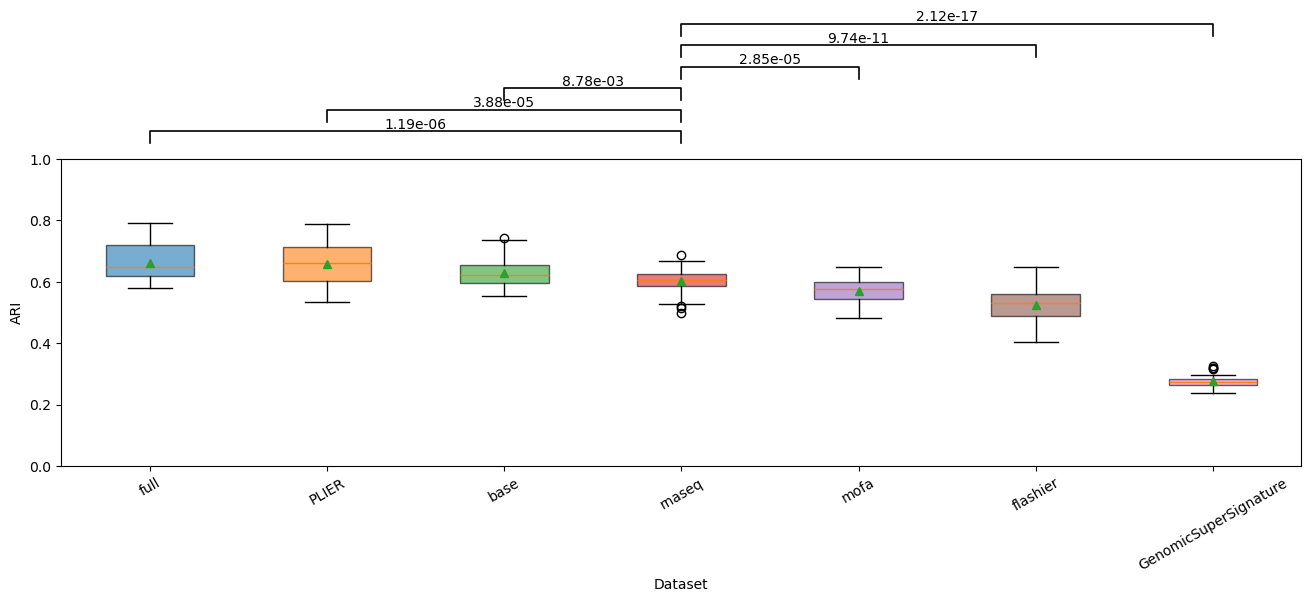

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
from scipy.stats import mannwhitneyu

candidate_names = [
    #"best_k_gtex_ica_kmeans_results_df",
    #"best_k_gtex_GTEx_Tissues_CLAMP_kmeans_results_df",
    #"best_k_gtex_KEGG_CLAMP_kmeans_results_df",
    #"best_k_gtex_GO_BP_CLAMP_kmeans_results_df",
    #"best_k_gtex_CellMarker_2024_kmeans_results_df",
    "best_k_gtex_base_kmeans_results_df",
    "best_k_gtex_full_kmeans_results_df",
    "best_k_gtex_PLIER_kmeans_results_df",
    "best_k_gtex_rnaseq_kmeans_results_df",
    #"best_k_gtex_archs4_projection",
    #"best_k_gtex_pca_kmeans_results_df",
    #"best_k_gtex_nmf_kmeans_results_df",
    'best_k_gtex_mofa_kmeans_results_df',
    'best_k_gtex_flashier_kmeans_results_df',
    "best_k_gtex_GenomicSuperSignature_kmeans_results_df"
]

datasets = {name: globals().get(name) for name in candidate_names}
datasets = {k: v for k, v in datasets.items() if v is not None and "ari" in v.columns and len(v)}

def clean_name(name: str) -> str:
    name = re.sub(r"^best_k_gtex_", "", name)
    name = re.sub(r"_kmeans_results_df$", "", name)
    return name

means = {name: df["ari"].mean() for name, df in datasets.items()}
ordered_names = sorted(means, key=lambda n: means[n], reverse=True)

data = [datasets[name]["ari"].to_numpy(float) for name in ordered_names]
labels = [clean_name(name) for name in ordered_names]

fig, ax = plt.subplots(figsize=(16, 10))

box = ax.boxplot(data, tick_labels=labels, showmeans=True, patch_artist=True)
for patch, color in zip(box["boxes"], plt.cm.tab10.colors * 3):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel("ARI")
ax.set_xlabel("Dataset")
plt.xticks(rotation=30, ha="center")

ax.set_ylim(0, 1)

# pairs = []
# pairs += [("rnaseq", lab) for lab in labels if lab != "rnaseq"]
# pairs += [("GO_BP_CLAMP", "nmf"), ("GO_BP_CLAMP", "pca")]

pairs = []
pairs += [("rnaseq", lab) for lab in labels if lab != "rnaseq"]

def mw_p_directional(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    if np.median(a) > np.median(b):
        return mannwhitneyu(a, b, alternative="greater").pvalue
    else:
        return mannwhitneyu(a, b, alternative="less").pvalue

raw_p = []
for a, b in pairs:
    i = labels.index(a)
    j = labels.index(b)
    raw_p.append(mw_p_directional(data[i], data[j]))

def fdr_bh(pvals):
    p = np.asarray(pvals, dtype=float)
    m = len(p)
    order = np.argsort(p)
    ranked = p[order]
    q = ranked * m / (np.arange(m) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    q_adj = np.empty_like(q)
    q_adj[order] = q
    return np.clip(q_adj, 0, 1)

pvals_adj = fdr_bh(raw_p)

xpos = {lab: x for lab, x in zip(labels, range(1, len(labels) + 1))}

def draw_bar(ax, x1, x2, y, h, txt):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c="black", clip_on=False)
    ax.text((x1 + x2) / 2, y + h, txt, ha="center", va="bottom", clip_on=False)

y_start = 1.05
bar_height = 0.04
gap = 0.03
y = y_start

for (a, b), adj_p in zip(pairs, pvals_adj):
    x1, x2 = sorted([xpos[a], xpos[b]])
    draw_bar(ax, x1, x2, y, bar_height, f"{adj_p:.2e}")
    y += bar_height + gap

total_height_needed = y - y_start
top_margin = 1 - (0.95 / (1 + total_height_needed * 1.5))
plt.subplots_adjust(top=top_margin)

plt.show()